In [3]:
import pandas as pd
import netCDF4 as nc
from matplotlib import pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

In [4]:
data_folder = "/home/j/Documents/IIASA/MM-Emulator"
data_file = "magpie_input_MP00BI00nov23.csv"
figure_folder = data_folder + "/figures/new/"
data_file_path = data_folder + "/" + data_file
data = pd.read_csv(data_file_path)
print("Figures: " + figure_folder)
print("Data: " + data_file_path)

Figures: /home/j/Documents/IIASA/MM-Emulator/figures/new/
Data: /home/j/Documents/IIASA/MM-Emulator/magpie_input_MP00BI00nov23.csv


# Data prep

## CO2 emissions

In [5]:
def add_year(df, year):
    if str(year) in df.columns:
        return df
    df[str(year)] =  (df[str(year-5)] + df[str(year+5)])/2
    return df

In [6]:
def sort_df_by_year(df):
    df_old = df.copy()
    for y in range(2020,2105,5):
        if str(y) in df.columns:
            df = df.drop(columns=[str(y)])
            df[str(y)] = df_old[str(y)]
    return df

In [7]:
df_co2 = data[(data['Region']=='World') & (data['BIOscen']=="BIO00") & (data['Variable']=="Emissions|CO2|AFOLU")]
df_co2 = df_co2.drop(columns=["Region" , "SSPscen", "BIOscen", "SDGscen", "1995", "2000", "2005", "2010", "2015", "2110"])
#df_co2

In [8]:
df_co2_cumu = df_co2.copy()
df_co2_cumu.iloc[:,3:16] = df_co2_cumu.iloc[:,3:16] * [5,5,5,5,5,5,5,5,5,10,10,10,10] / 1000
#df_co2_cumu['cumu'] = df_co2_cumu.sum(axis=1, numeric_only=True)
for i in range(4,16):
    df_co2_cumu.iloc[:,i] = df_co2_cumu.iloc[:,i] + df_co2_cumu.iloc[:,i-1]
#df_co2_cumu = df_co2_cumu.drop(columns=["2020", "2025", "2030", "2035", "2040", "2045", "2050", "2055", "2060", "2070", "2080", "2090", "2100"])
df_co2_cumu["Variable"] = "Emissions|CO2|AFOLU|Cumulative"
df_co2_cumu["Unit"] = "Gt CO2"
for y in [2065, 2075, 2085, 2095]:
    df_co2_cumu = add_year(df_co2_cumu,y)
df_co2_cumu = sort_df_by_year(df_co2_cumu)
df_co2_cumu

,Variable,Unit,GHGscen,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
480,Emissions|CO2|AFOLU|Cumulative,Gt CO2,GHG000,27.196939,49.488112,71.966226,94.121368,114.184309,131.800395,149.703246,171.783080,198.942634,227.376619,255.810604,280.084777,304.358951,322.297521,340.236090,353.411363,366.586637
2014,Emissions|CO2|AFOLU|Cumulative,Gt CO2,GHG010,27.196939,48.349401,68.470889,87.044569,103.375593,117.851779,132.074775,147.782559,165.270215,182.761545,200.252874,214.841746,229.430618,239.716175,250.001731,257.016772,264.031813
3548,Emissions|CO2|AFOLU|Cumulative,Gt CO2,GHG020,27.196939,46.795750,64.150361,79.413791,92.363024,102.954089,112.198307,122.305210,134.542182,147.400603,160.259023,171.010325,181.761627,189.407646,197.053666,201.332697,205.611729
5082,Emissions|CO2|AFOLU|Cumulative,Gt CO2,GHG050,27.196939,46.106797,63.119332,78.675197,92.049713,102.422593,110.376673,117.646122,125.252510,132.935332,140.618153,146.304285,151.990418,156.530536,161.070654,164.256142,167.441631
6616,Emissions|CO2|AFOLU|Cumulative,Gt CO2,GHG100,27.196939,44.645347,59.241892,71.528161,81.569333,89.551162,96.487700,103.390963,109.247079,114.553625,119.860171,123.953455,128.046739,130.523859,133.000979,134.261626,135.522273
8150,Emissions|CO2|AFOLU|Cumulative,Gt CO2,GHG200,27.196939,43.778203,57.403195,68.878849,77.815433,83.946905,88.991889,94.019095,99.106533,103.392985,107.679436,110.482989,113.286541,114.210527,115.134513,114.134334,113.134154
9684,Emissions|CO2|AFOLU|Cumulative,Gt CO2,GHG400,27.196939,41.343139,51.790410,59.250674,64.875103,69.171799,72.828409,76.226316,79.256430,81.193024,83.129617,83.615091,84.100565,82.737107,81.373648,78.949533,76.525417
11218,Emissions|CO2|AFOLU|Cumulative,Gt CO2,GHG600,27.196939,40.507885,50.043588,56.924359,61.991974,65.733745,68.815907,71.431147,73.181146,73.192844,73.204541,71.696710,70.188879,67.253261,64.317643,59.920661,55.523678
12752,Emissions|CO2|AFOLU|Cumulative,Gt CO2,GHG1000,27.196939,40.217207,49.357227,55.689762,59.955477,62.433958,63.491716,63.351812,62.468651,60.349749,58.230847,54.282358,50.333869,44.365763,38.397657,30.984374,23.571091
14286,Emissions|CO2|AFOLU|Cumulative,Gt CO2,GHG2000,27.196939,39.402468,47.282543,51.741141,53.458858,52.534330,50.020815,46.341734,40.997756,33.746123,26.494490,18.205379,9.916268,0.903336,-8.109596,-18.040505,-27.971414


In [9]:
ghgs = ["GHG000", "GHG050", "GHG400", "GHG4000"]
co2_y = df_co2_cumu[df_co2_cumu['GHGscen'].isin(ghgs)]
co2_y = co2_y.drop(columns=["Variable", "Unit"]).transpose()
#co2_y.iloc[0,:]
co2_y = co2_y.rename(columns={480: "GHG000", 5082: "GHG050", 9684: "GHG400", 17354: "GHG4000"})
co2_y = co2_y.drop('GHGscen')
co2_y = co2_y.astype(float)
co2_y["Year"] = co2_y.index.astype(int)
co2_y


,GHG000,GHG050,GHG400,GHG4000,Year
2020,27.196939,27.196939,27.196939,27.196939,2020
2025,49.488112,46.106797,41.343139,37.512668,2025
2030,71.966226,63.119332,51.790410,41.967889,2030
2035,94.121368,78.675197,59.250674,42.254819,2035
2040,114.184309,92.049713,64.875103,39.182693,2040
2045,131.800395,102.422593,69.171799,33.105103,2045
2050,149.703246,110.376673,72.828409,25.009079,2050
2055,171.783080,117.646122,76.226316,16.060224,2055
2060,198.942634,125.252510,79.256430,6.898626,2060
2065,227.376619,132.935332,81.193024,-2.771110,2065


## BII

In [10]:
df_bii = data[(data['Region']=='World') & (data['BIOscen']=="BIO00") & (data['Variable']=="Biodiversity|BII") & data['GHGscen'].isin(ghgs)] 
df_bii = df_bii.drop(columns=["Region" , "SSPscen", "BIOscen", "SDGscen", "2110"])
for y in [2065, 2075, 2085, 2095]:
    df_bii = add_year(df_bii,y)
df_bii = sort_df_by_year(df_bii)


In [11]:
df_bii_ghg = df_bii.drop(columns=["Variable", "Unit"]).transpose()
df_bii_ghg = df_bii_ghg.rename(columns={324: "GHG000", 4926: "GHG050", 9528: "GHG400", 17198: "GHG4000"})
df_bii_ghg = df_bii_ghg.drop('GHGscen')
df_bii_ghg["Year"] = df_bii_ghg.index
df_bii_ghg["Year"] = df_bii_ghg["Year"].astype("int")
df_bii_ghg


,GHG000,GHG050,GHG400,GHG4000,Year
1995,0.7997,0.7997,0.7997,0.7997,1995
2000,0.7992,0.7992,0.7992,0.7992,2000
2005,0.7986,0.7986,0.7986,0.7986,2005
2010,0.7971,0.7971,0.7971,0.7971,2010
2015,0.7953,0.7953,0.7953,0.7953,2015
2020,0.7942,0.7942,0.7942,0.7942,2020
2025,0.7933,0.7935,0.7937,0.7944,2025
2030,0.7922,0.7926,0.7935,0.796,2030
2035,0.7912,0.7918,0.7931,0.7969,2035
2040,0.7902,0.7912,0.7931,0.7982,2040


## Land Use

In [12]:
land_types = ["Land Cover|Cropland", "Land Cover|Forest", "Land Cover|Other Land", "Land Cover|Pasture"]
df_land = data[(data['Region']=='World') & (data['BIOscen']=="BIO00") & data['GHGscen'].isin(ghgs) & data['Variable'].isin(land_types) ] 
df_land = df_land.drop(columns=["Region" , "SSPscen", "BIOscen", "SDGscen", "2110"])
#for y in [2065, 2075, 2085, 2095]:
#    df_land = add_year(df_land,y)
#df_land = sort_df_by_year(df_land)
df_land["Variable"] = df_land["Variable"].str.replace("Land Cover|", "")
df_land

,Variable,Unit,GHGscen,1995,2000,2005,2010,2015,2020,2025,...,2035,2040,2045,2050,2055,2060,2070,2080,2090,2100
935,Cropland,million ha,GHG000,1469.1559,1471.6257,1475.9538,1510.0286,1580.3780,1615.9719,1650.0620,...,1750.1331,1785.4406,1821.4732,1829.5186,1861.6728,1914.3566,2020.0698,2129.9058,2195.1333,2245.0627
1026,Forest,million ha,GHG000,4040.1376,4038.2434,4034.1238,4016.3582,3972.8080,3950.1161,3945.8322,...,3901.8697,3878.0548,3851.8311,3844.2987,3824.8368,3796.6265,3711.1852,3618.6364,3594.8547,3580.7819
1130,Other Land,million ha,GHG000,3965.1134,3952.1587,3945.0142,3921.8455,3890.2620,3881.5942,3849.7243,...,3791.5178,3774.3830,3762.0478,3757.5049,3753.2169,3736.0086,3707.2477,3699.0303,3671.4349,3663.4845
1143,Pasture,million ha,GHG000,3251.5087,3263.8877,3270.8238,3277.6833,3282.4677,3278.2334,3280.2970,...,3282.3949,3288.0372,3290.5634,3294.5933,3286.1891,3278.9238,3287.4127,3278.3430,3264.4927,3236.5864
5537,Cropland,million ha,GHG050,1469.1559,1471.6257,1475.9538,1510.0286,1580.3780,1615.9719,1646.3319,...,1736.6153,1767.8347,1797.7141,1808.6335,1835.6969,1872.8781,1930.8896,1979.1433,2016.1819,2043.3646
5628,Forest,million ha,GHG050,4040.1376,4038.2434,4034.1238,4016.3582,3972.8080,3950.1161,3942.6616,...,3909.1737,3897.1897,3876.4166,3873.8975,3872.5207,3854.0969,3840.5368,3827.5648,3806.8488,3814.7871
5732,Other Land,million ha,GHG050,3965.1134,3952.1587,3945.0142,3921.8455,3890.2620,3881.5942,3856.7803,...,3805.4540,3781.9242,3771.0178,3759.6529,3744.4849,3732.4941,3704.5206,3686.7115,3673.9255,3689.8818
5745,Pasture,million ha,GHG050,3251.5087,3263.8877,3270.8238,3277.6833,3282.4677,3278.2334,3280.1418,...,3274.6725,3278.9669,3280.7669,3283.7316,3273.2130,3266.4464,3249.9685,3232.4958,3228.9593,3177.8821
10139,Cropland,million ha,GHG400,1469.1559,1471.6257,1475.9538,1510.0286,1580.3780,1615.9719,1639.6529,...,1702.8607,1720.1897,1743.0052,1747.9510,1766.3767,1798.1561,1824.7049,1852.7743,1868.6253,1883.7348
10230,Forest,million ha,GHG400,4040.1376,4038.2434,4034.1238,4016.3582,3972.8080,3950.1161,3946.5596,...,3937.5054,3927.6992,3926.0105,3925.1891,3923.8533,3928.1881,3930.8123,3940.7776,3957.0051,3985.1073


In [13]:
df_land_ghg = df_land.copy()
def prepare_land_df(land,indexm):
    df_land_part = df_land_ghg[df_land_ghg['Variable']==land].drop(columns=['Unit'])
    df_land_part = df_land_part.reset_index().drop(columns=['index'])
    df_land_part = df_land_part.transpose()
    df_land_part["Year"] = df_land_part.index
    df_land_part["Land"] = land
    df_land_part = df_land_part.rename(columns={0: "GHG000", 1: "GHG050", 2: "GHG400", 3: "GHG4000"})
    df_land_part = df_land_part.drop(["Variable", "GHGscen"])
    df_land_part = df_land_part.reset_index().drop(columns=['index'])
    df_land_part.index += len(df_land_part.index) * indexm
    df_land_part["Year"] = df_land_part["Year"].astype("int")
    return df_land_part

In [14]:
land_short = ["Cropland", "Forest", "Other Land", "Pasture"]

df_land_full = pd.DataFrame()
for i in range(len(land_short)):
    df_land_full = pd.concat([df_land_full,prepare_land_df(land_short[i],i)])
df_land_full

,GHG000,GHG050,GHG400,GHG4000,Year,Land
0,1469.1559,1469.1559,1469.1559,1469.1559,1995,Cropland
1,1471.6257,1471.6257,1471.6257,1471.6257,2000,Cropland
2,1475.9538,1475.9538,1475.9538,1475.9538,2005,Cropland
3,1510.0286,1510.0286,1510.0286,1510.0286,2010,Cropland
4,1580.378,1580.378,1580.378,1580.378,2015,Cropland
...,...,...,...,...,...,...
67,3278.9238,3266.4464,3206.784,2978.9598,2060,Pasture
68,3287.4127,3249.9685,3101.5867,2880.6969,2070,Pasture
69,3278.343,3232.4958,2975.6786,2784.5503,2080,Pasture
70,3264.4927,3228.9593,2859.8964,2671.6389,2090,Pasture


# Plots

## Definitions

In [15]:
# Color Scheme (default too dark) PuOr: ['#e66101','#fdb863', '#b2abd2', '#5e3c99']
cmap_PuOr = ListedColormap(['#e66101','#fdb863', '#b2abd2', '#5e3c99'])
ghg_labels = ["Baseline", "Low", "Medium" ,"High Climate Policy Stringency"]
fs = 20
fs_redux = 15


## Subplot 1: Cumulative emissions

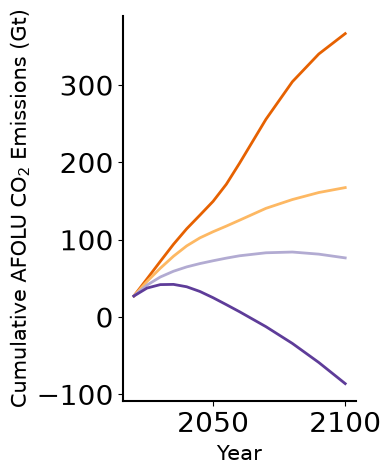

In [16]:
#fig_1_1 = plt.figure(figsize=(5, 5))
plot1_1 = co2_y.plot(
    x='Year',
    y=ghgs,
    colormap=cmap_PuOr,
    figsize=(3, 5),
    linewidth=2,
    legend=None
)

for axis in ['top','bottom','left','right']:
    plot1_1.spines[axis].set_linewidth(1.5)
plot1_1.spines.right.set_visible(False)
plot1_1.spines.top.set_visible(False)

plot1_1.set_xlabel("Year", fontsize = fs_redux)
plot1_1.set_ylabel(r"Cumulative AFOLU CO$_2$ Emissions (Gt)", fontsize = fs_redux)
plot1_1.tick_params(axis='both', which='major', labelsize=fs)

#handles, labels = plot1_1.get_legend_handles_labels()
#plot1_1.legend(handles, ghg_labels,loc="lower center", bbox_to_anchor=(0.5, -0.30), ncol=len(co2_y.columns), fontsize = 15)

fig1_1 = plot1_1.get_figure()
fig1_1.savefig(figure_folder + "fig1_1.png", bbox_inches = "tight")

## Subplot 2: BII

In [17]:
df_bii_ghg

,GHG000,GHG050,GHG400,GHG4000,Year
1995,0.7997,0.7997,0.7997,0.7997,1995
2000,0.7992,0.7992,0.7992,0.7992,2000
2005,0.7986,0.7986,0.7986,0.7986,2005
2010,0.7971,0.7971,0.7971,0.7971,2010
2015,0.7953,0.7953,0.7953,0.7953,2015
2020,0.7942,0.7942,0.7942,0.7942,2020
2025,0.7933,0.7935,0.7937,0.7944,2025
2030,0.7922,0.7926,0.7935,0.796,2030
2035,0.7912,0.7918,0.7931,0.7969,2035
2040,0.7902,0.7912,0.7931,0.7982,2040


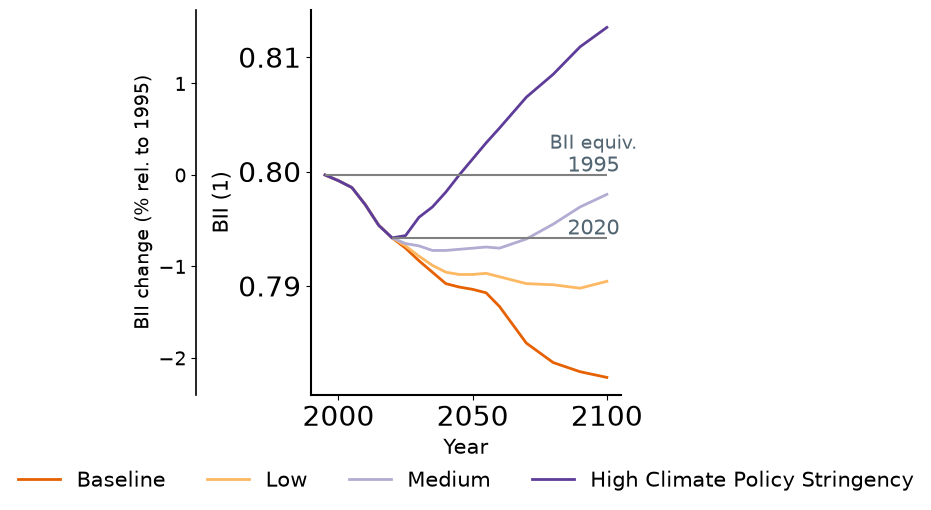

In [18]:
plot1_2 = df_bii_ghg.plot(
    x="Year",
    y=ghgs,
    colormap=cmap_PuOr, 
    figsize=(4, 5),
    linewidth=2,
    legend=None,
    xticks=[2000,2050,2100],
    yticks=[0.79,0.80,0.81]
    )

for axis in ['top','bottom','left','right']:
    plot1_2.spines[axis].set_linewidth(1.5)
plot1_2.spines.right.set_visible(False)
plot1_2.spines.top.set_visible(False)
plot1_2.set_xlabel("Year", fontsize = fs_redux)
plot1_2.set_ylabel("BII (1)", fontsize = fs_redux)
plot1_2.tick_params(axis='both', which='major', labelsize=fs)

plot1_2.hlines(df_bii_ghg['GHG000'].iloc[0], xmin=1995,xmax=2100,colors='gray')
plot1_2.hlines(df_bii_ghg['GHG000'].iloc[5], xmin=2020,xmax=2100,colors='gray')
plot1_2.text(x=2095, y=0.802, s="BII equiv.", color='#516572', ha='center', fontsize=fs_redux-1)
plot1_2.text(x=2095, y=df_bii_ghg['GHG000'].iloc[0]+0.0003, s="1995", color='#516572', ha='center', fontsize=fs_redux)
plot1_2.text(x=2095, y=df_bii_ghg['GHG000'].iloc[5]+0.0003, s="2020", color='#516572', ha='center', fontsize=fs_redux)

def bii_to_rel(x):
    return ((x / df_bii_ghg['GHG000'].iloc[0])-1) * 100

def rel_to_bii(x):
    return (x / 100 + 1) * df_bii_ghg['GHG000'].iloc[0]

secax_y2 = plot1_2.secondary_yaxis(-0.37, functions=(bii_to_rel, rel_to_bii))
secax_y2.set_yticks([-2,-1,0,1])
secax_y2.spines["left"].set_linewidth(1.2)
secax_y2.tick_params(axis='both', which='major', labelsize=fs_redux-1)
secax_y2.set_ylabel("BII change (% rel. to 1995)", fontsize = fs_redux-1)


fig1_2 = plot1_2.get_figure()
fig1_2.savefig(figure_folder + "fig1_2.png", bbox_inches = "tight")

handles, labels = plot1_2.get_legend_handles_labels()
plot1_2.legend(handles, ghg_labels,loc="lower center", bbox_to_anchor=(0.5, -0.3), ncol=len(co2_y.columns), fontsize = fs_redux, frameon=False)

fig1_2 = plot1_2.get_figure()
fig1_2.savefig(figure_folder + "fig1_2+legend.png", bbox_inches = "tight")

## Subplot 3: Land use

In [19]:
df_land_full

,GHG000,GHG050,GHG400,GHG4000,Year,Land
0,1469.1559,1469.1559,1469.1559,1469.1559,1995,Cropland
1,1471.6257,1471.6257,1471.6257,1471.6257,2000,Cropland
2,1475.9538,1475.9538,1475.9538,1475.9538,2005,Cropland
3,1510.0286,1510.0286,1510.0286,1510.0286,2010,Cropland
4,1580.378,1580.378,1580.378,1580.378,2015,Cropland
...,...,...,...,...,...,...
67,3278.9238,3266.4464,3206.784,2978.9598,2060,Pasture
68,3287.4127,3249.9685,3101.5867,2880.6969,2070,Pasture
69,3278.343,3232.4958,2975.6786,2784.5503,2080,Pasture
70,3264.4927,3228.9593,2859.8964,2671.6389,2090,Pasture


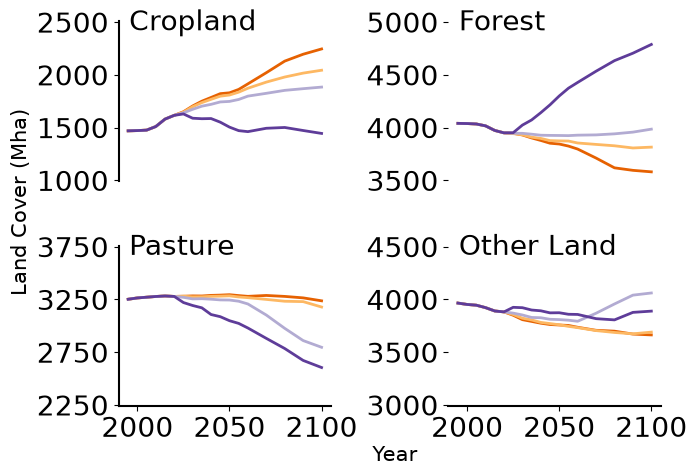

In [20]:
def create_subplot(landtype, axis, ylow):
    df = df_land_full[df_land_full['Land']==landtype]
    new_lim = [ylow-10, ylow+1510]
    new_ticks = [ylow, ylow+500, ylow+1000, ylow+1500]
    splot = df.plot(
       ax=axis,
       x="Year",
       y=ghgs,
       colormap=cmap_PuOr, 
       linewidth=2,
       legend=None,
       xticks=[2000,2050,2100],
       yticks=new_ticks,
       ylim=new_lim,
       xlabel=""
    )
    
    splot.tick_params(axis='both', which='major', labelsize=fs)
    for axis in ['top','bottom','left','right']:
        splot.spines[axis].set_linewidth(1.5)
    splot.spines.right.set_visible(False)
    splot.spines.top.set_visible(False)
    if landtype == "Cropland":
        splot.get_xaxis().set_visible(False)
        splot.spines.bottom.set_visible(False)
    elif landtype == "Forest":
        splot.spines.left.set_visible(False)
        splot.get_xaxis().set_visible(False)
        splot.spines.bottom.set_visible(False)
    elif landtype == "Other Land":
        splot.spines.left.set_visible(False)
    splot.set_title(landtype, x=0.05, y=0.89, horizontalalignment = "left", fontsize = fs)



fig1_3, axes = plt.subplots(nrows=2, ncols=2, figsize=(7, 5))
fig1_3.subplots_adjust(wspace=0.55, hspace=0.4)


create_subplot("Cropland", axes[0,0], ylow = 1000)
create_subplot("Forest", axes[0,1], ylow =3500)
create_subplot("Pasture", axes[1,0], ylow = 2250)
create_subplot("Other Land", axes[1,1], ylow = 3000)

fig1_3.text(x=0.52, y=-0, s="Year", ha='center', fontsize=fs_redux)
fig1_3.text(x=-0.03, y=0.34, s="Land Cover (Mha)", fontsize=fs_redux, rotation=90)


fig1_3.savefig(figure_folder + "fig1_3.png", bbox_inches = "tight")

## Subplot 4: Maps

In [21]:
ncname = "cell.bii_0.5.nc"
ncpath_base = "/DisaggData/BII00/GHG000/"
ncpath_high = "/DisaggData/BII00/GHG4000/"
ncfname_base = data_folder + ncpath_base  + ncname
ncfname_high = data_folder + ncpath_high  + ncname

In [22]:
def netcdf_delta_prep(ncf_path):
    xrds = xr.open_dataset(ncf_path)
    return xrds.sel(Time=2100)-xrds.sel(Time=1995)

In [23]:
delta_base = netcdf_delta_prep(ncfname_base)
delta_high = netcdf_delta_prep(ncfname_high)

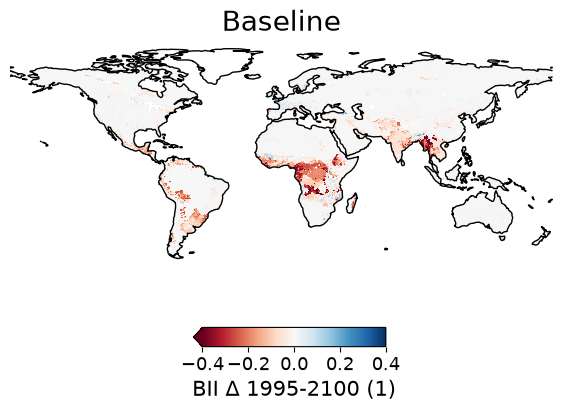

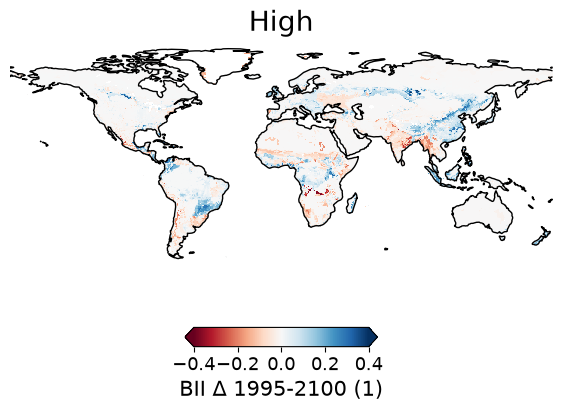

In [24]:
def plot_bii_map(ncf_path, title = "test", cb=False):
    nc = data_folder + ncf_path + ncname
    delta = netcdf_delta_prep(nc)
    fig = plt.figure(figsize=(7, 5), facecolor='white')
    ax = plt.axes(projection=ccrs.PlateCarree(), ylim=[-63,90], frameon=False)
    vm = 0.4
    map = 0
    if cb:
        map = delta['Variable'].plot(ax=ax,transform=ccrs.PlateCarree(), vmin=-vm, vmax=vm, cmap='RdBu', cbar_kwargs={'ticks': [-vm,-vm/2,0,vm/2,vm], 'location':"bottom", 'fraction':0.05, 'aspect': 10})
        map.colorbar.ax.tick_params(labelsize=fs_redux-2)
        map.colorbar.set_label(label = r'BII $\Delta$ 1995-2100 (1)', size=fs_redux)

    else:
        map = delta['Variable'].plot(ax=ax,transform=ccrs.PlateCarree(), vmin=-vm, vmax=vm, cmap='RdBu', add_colorbar=False)
    ax.coastlines()
    plt.title(title, loc='center',fontsize = fs, horizontalalignment = "center")
    return fig


map_base = plot_bii_map(ncpath_base, "Baseline", True)
map_base.savefig(figure_folder + "fig1_4a+legend.png", bbox_inches = "tight")

map_high = plot_bii_map(ncpath_high, "High", True)
map_high.savefig(figure_folder + "fig1_4b+legend.png", bbox_inches = "tight")


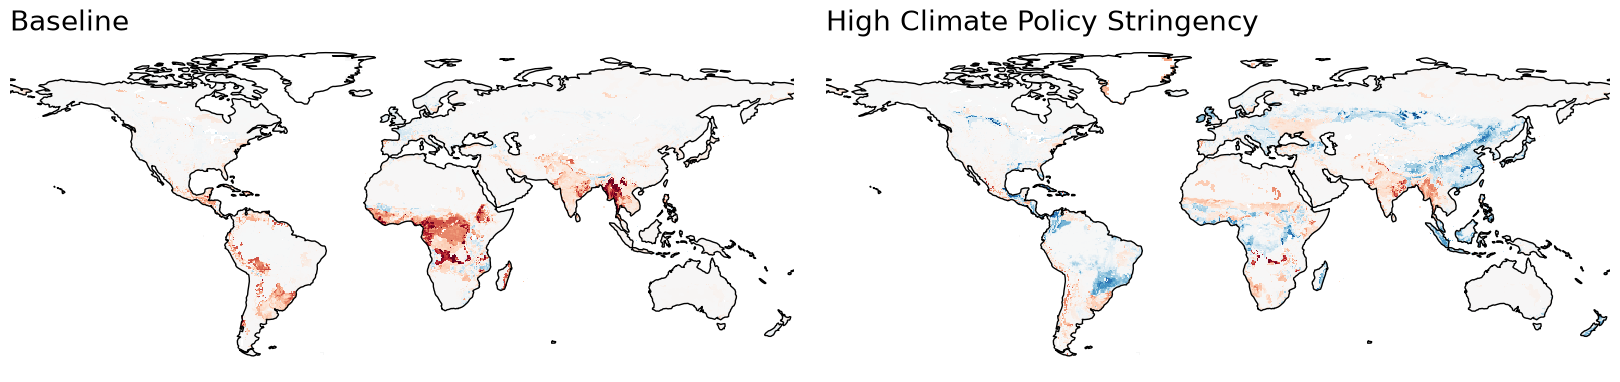

In [25]:
def plot_bii_ax(ncf_path, axis, title = "test", cb=False):
    nc = data_folder + ncf_path + ncname
    delta = netcdf_delta_prep(nc)
    #fig = plt.figure(figsize=(7, 5), facecolor='white')
    #axis = plt.axes(ax=axis, projection=ccrs.PlateCarree(), ylim=[-63,90], frameon=False)
    vm = 0.4
    map = 0
    if cb:
        map = delta['Variable'].plot(ax=axis,transform=ccrs.PlateCarree(), vmin=-vm, vmax=vm, cmap='RdBu', cbar_kwargs={'ticks': [-vm,-vm/2,0,vm/2,vm], 'location':"bottom", 'fraction':0.1, 'aspect': 10})
        map.colorbar.axis.tick_params(labelsize=fs)
        map.colorbar.set_label(label = r'BII $\Delta$ 1995-2100', size=fs_redux)

    else:
        map = delta['Variable'].plot(ax=axis,transform=ccrs.PlateCarree(), vmin=-vm, vmax=vm, cmap='RdBu', add_colorbar=False)
    axis.coastlines()
    axis.set_title(title, loc='left',fontsize = fs, horizontalalignment = "left")

#fig1_4, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
fig1_4, axes = plt.subplots(1, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree(), 'ylim':[-63,90], 'frameon':False})
plot_bii_ax(ncpath_base, axes[0], "Baseline", False)
plot_bii_ax(ncpath_high, axes[1], "High Climate Policy Stringency", False)
axes[0].set_position([0, 0, 0.49, 0.49])
axes[1].set_position([0.51, 0, 0.49, 0.49])

fig1_4.savefig(figure_folder + "fig1_4.png", bbox_inches = "tight")
